In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("d:\python\student_data_clean.csv")
df.columns

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
C:\Users\momin\AppData\Local\Temp\ipykernel_14804\2675159989.py:5: SyntaxWarning: invalid escape sequence '\p'
  df=pd.read_csv("d:\python\student_data_clean.csv")


Index(['Student_ID', 'Name', 'Age', 'Gender', 'Department', 'Semester', 'CGPA',
       'Attendance_Rate', 'Scholarship', 'Admission_Date', 'Midterm_Marks',
       'Final_Marks', 'City', 'Study_Hours_Per_Day', 'Fees_Paid'],
      dtype='str')

<Axes: xlabel='Gender'>

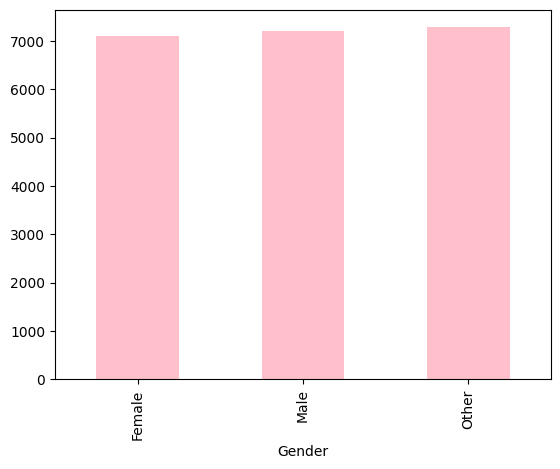

In [136]:
df.pivot_table(values="Age",index="Department",columns="Gender",aggfunc="sum")
df.groupby('Gender')['Age'].sum().sort_values().plot(kind='bar',color='pink',)

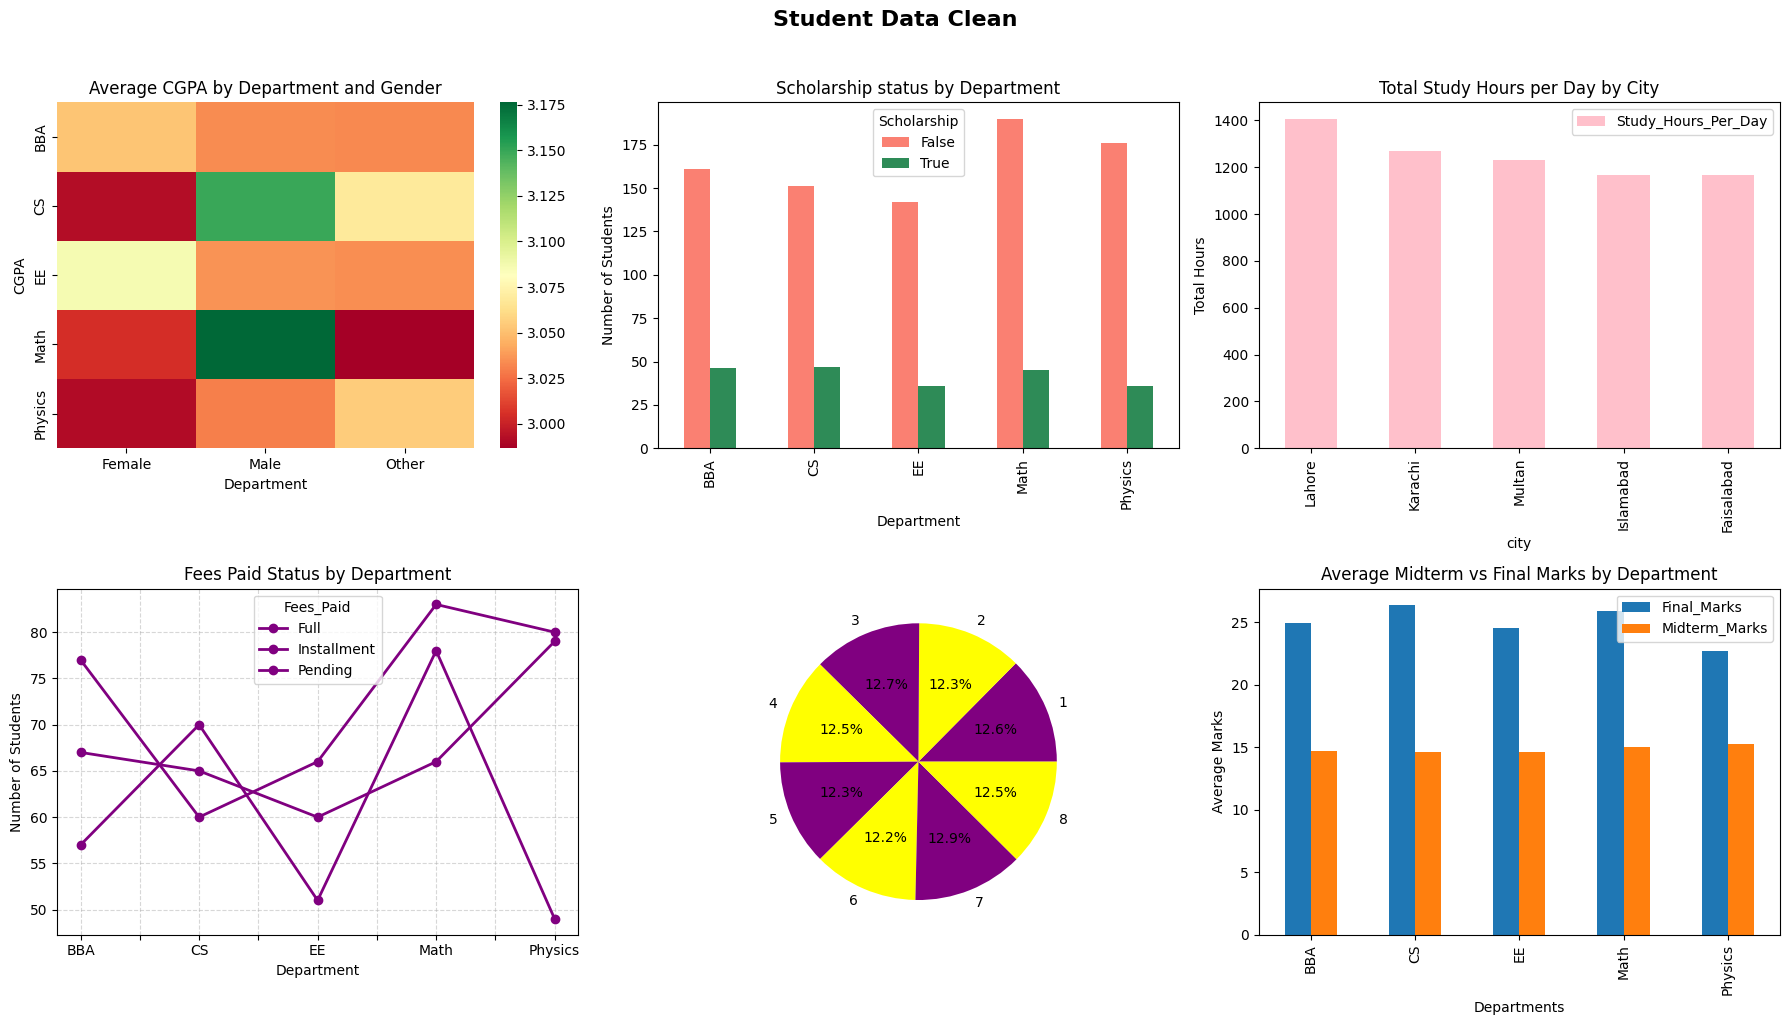

In [149]:
# 9. DASHBOARD - Multiple business metrics
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
#1. Heatmap: Performance Matrix (Dept vs Gender)
# Shows average CGPA for each category
performance_matrix = df.pivot_table(values='CGPA', index='Department', columns='Gender', aggfunc='mean')

sns.heatmap(performance_matrix, cmap='RdYlGn', ax=axes[0,0])
plt.title('Average CGPA by Department and Gender')


axes[0,0].set_title('Average CGPA by Department and Gender')
axes[0,0].set_xlabel('Department')
axes[0,0].set_ylabel('CGPA')

#2. Stacked Bar: Scholarship Status by Department
# Shows how many students have scholarships in each department
scholarship_status = df.pivot_table(values='Student_ID', index='Department', columns='Scholarship', aggfunc='count')
scholarship_status.plot(kind='bar', ax=axes[0,1], color=['salmon', 'seagreen'] )
axes[0,1].set_title('Scholarship status by Department')
axes[0,1].set_ylabel("Number of Students")
axes[0,1].set_xlabel("Department")

#3. Bar Chart: Total Study Hours by City 
# Identifies which city contributes most to overall study effort
pivot_city_study = df.pivot_table(values='Study_Hours_Per_Day', index='City', aggfunc='sum').sort_values(by='Study_Hours_Per_Day', ascending=False)
pivot_city_study.plot(kind='bar', ax=axes[0,2], color='pink' )
axes[0,2].set_title('Total Study Hours per Day by City')
axes[0,2].set_ylabel('Total Hours')
axes[0,2].set_xlabel("city")

#4 fees paid by the department
#identify which department have more pending payment
fees_paid = df.pivot_table(values="Student_ID", index="Department", columns="Fees_Paid", aggfunc="count")
fees_paid.plot(kind='line', marker='o', ax=axes[1,0], color='purple', linewidth=2)
axes[1,0].set_title('Fees Paid Status by Department')
axes[1,0].set_ylabel('Number of Students')
axes[1,0].set_xlabel("Department")
axes[1,0].grid(True, linestyle='--', alpha=0.5)

#5 Attendance Trend by Semester
#students become more or less regular 
attendance_semester = df.pivot_table(values='Attendance_Rate', index='Semester', aggfunc='mean')

attendance_semester['Attendance_Rate'].plot(
    kind='pie',
    colors=["purple","yellow"],
    autopct='%1.1f%%',
    ax=axes[1,1]
)




#6 Grouped Bar: Average Midterm vs Final Marks 
# Compares performance across two different metrics
pivot_marks = df.pivot_table(values=['Midterm_Marks', 'Final_Marks'], index='Department', aggfunc='mean')
pivot_marks.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Average Midterm vs Final Marks by Department')
axes[1,2].set_ylabel('Average Marks')
axes[1,2].set_xlabel('Departments')

plt.suptitle('Student Data Clean', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()